# FASE 4: DASHBOARD EJECUTIVO Y ANÁLISIS DE IMPACTO DE NEGOCIO

## 📌 Contexto del Proyecto
En las fases anteriores limpiamos los datos (Fase 2), entrenamos y comparamos modelos de Machine Learning (Fase 3), y exportamos las predicciones finales con el `customerID` de cada cliente, su probabilidad real de Churn (calculada por el modelo, no estimada manualmente) y el ranking de variables más influyentes.

## 🎯 Objetivo de este Notebook
Construir un dashboard de validación que traduzca las predicciones del modelo en información de negocio: KPIs del modelo, segmentación de clientes por riesgo, **impacto financiero (MRR en riesgo)**, correlación entre tipo de contrato y probabilidad de fuga, un mapa de vulnerabilidad (antigüedad vs cargos mensuales), y una lista priorizada de clientes a contactar.

## ⚠️ Nota importante sobre la fuente de los datos
Todas las probabilidades de Churn usadas aquí (`probabilidad_churn`) provienen del modelo real entrenado en la Fase 3 (exportado en `predicciones_churn_dashboard.csv`). **No se simula ni se inventa ninguna probabilidad con reglas manuales o números aleatorios** — el dashboard solo es confiable si refleja lo que el modelo realmente aprendió de los datos.

## ⚙️ Estructura
1. **Carga y enriquecimiento:** predicciones reales de la Fase 3 + variables de negocio (Contract, MonthlyCharges, tenure) del dataset original, unidas por `customerID`.
2. **KPIs Ejecutivos del Modelo:** Recall, Precision, F1, Accuracy.
3. **Matriz de Confusión.**
4. **Distribución de probabilidad de Churn** (diagnóstico de separación del modelo).
5. **Dashboard Visual Ejecutivo (panel 2x2):** volumen por banda de riesgo, **MRR (Ingreso Mensual Recurrente) en riesgo**, probabilidad de Churn por tipo de contrato, y mapa de vulnerabilidad (tenure vs cargos mensuales). Se exporta como imagen PNG para usar en la sustentación.
6. **Factores clave de Churn:** ranking visual de variables (Random Forest).
7. **Lista priorizada de retención**, ahora con contexto de negocio (contrato y cargo mensual).
8. **Exportación final** de la lista priorizada para Power BI / campaña de retención.

## 1. Carga de predicciones reales + enriquecimiento con datos de negocio

In [1]:
# ==============================================================================
# 1. CARGAR PREDICCIONES REALES (FASE 3) + DATOS DE NEGOCIO (CSV ORIGINAL)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, confusion_matrix

sns.set_style("whitegrid")

predicciones = pd.read_csv("../data/sample/predicciones_churn_dashboard.csv")
importancias = pd.read_csv("../data/sample/importancia_variables_churn.csv")

importancias = pd.read_csv("../data/sample/importancia_variables_churn.csv")

# Recuperamos SOLO variables de negocio del dataset original (Contract, MonthlyCharges, tenure).
# Importante: 'probabilidad_churn' NO se vuelve a calcular ni se simula aquí, ya viene del modelo.
df_negocio = pd.read_csv("../data/sample/WA_Fn-UseC_-Telco-Customer-Churn.csv")[
    ["customerID", "Contract", "MonthlyCharges", "tenure"]
]

df = predicciones.merge(df_negocio, on="customerID", how="left")

print(f"Predicciones cargadas: {df.shape[0]} clientes")
df.head()

Predicciones cargadas: 2007 clientes


,customerID,churn_real,churn_predicho,probabilidad_churn,Contract,MonthlyCharges,tenure
0,0004-TLHLJ,1,1.0,0.668508,Month-to-month,73.90,4
1,0013-SMEOE,0,0.0,0.070670,Two year,109.70,71
2,0015-UOCOJ,0,1.0,0.397242,Month-to-month,48.20,7
3,0016-QLJIS,0,0.0,0.039342,Two year,90.45,65
4,0019-EFAEP,0,0.0,0.074042,Two year,101.30,72


## 2. KPIs Ejecutivos del Modelo

In [2]:
# ==============================================================================
# 2. KPIs EJECUTIVOS
# ==============================================================================
y_real = df["churn_real"]
y_pred = df["churn_predicho"]

recall = recall_score(y_real, y_pred)
precision = precision_score(y_real, y_pred)
f1 = f1_score(y_real, y_pred)
accuracy = accuracy_score(y_real, y_pred)

total_clientes = len(df)
clientes_riesgo = int((y_pred == 1).sum())
tasa_churn_real = y_real.mean()

print("=" * 55)
print("RESUMEN EJECUTIVO - MODELO DE PREDICCIÓN DE CHURN")
print("=" * 55)
print(f"Total de clientes analizados:      {total_clientes:,}")
print(f"Clientes marcados en riesgo:       {clientes_riesgo:,} ({clientes_riesgo/total_clientes:.1%})")
print(f"Tasa real de Churn en el dataset:  {tasa_churn_real:.1%}")
estado_meta = "✅ cumple la meta (>80%)" if recall > 0.80 else "⚠️ por debajo de la meta (80%)"
print(f"Recall del modelo (Churn=1):       {recall:.1%}  -> {estado_meta}")
print(f"Precision del modelo (Churn=1):    {precision:.1%}")
print(f"F1-Score (Churn=1):                {f1:.1%}")
print(f"Accuracy general:                  {accuracy:.1%}")

RESUMEN EJECUTIVO - MODELO DE PREDICCIÓN DE CHURN
Total de clientes analizados:      2,007
Clientes marcados en riesgo:       635 (31.6%)
Tasa real de Churn en el dataset:  26.4%
Recall del modelo (Churn=1):       69.2%  -> ⚠️ por debajo de la meta (80%)
Precision del modelo (Churn=1):    57.8%
F1-Score (Churn=1):                63.0%
Accuracy general:                  78.5%


## 3. Matriz de Confusión

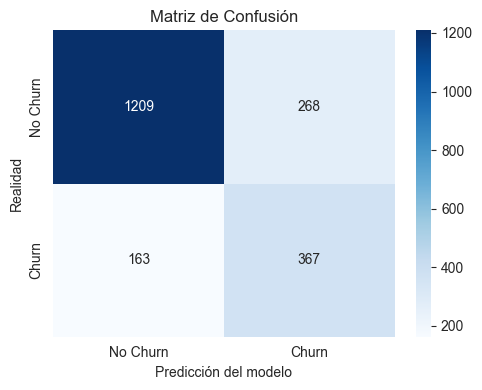

In [3]:
# ==============================================================================
# 3. MATRIZ DE CONFUSIÓN (VISUAL)
# ==============================================================================
cm = confusion_matrix(y_real, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn']
)
plt.xlabel('Predicción del modelo')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

## 4. Distribución de probabilidad de Churn (diagnóstico del modelo)

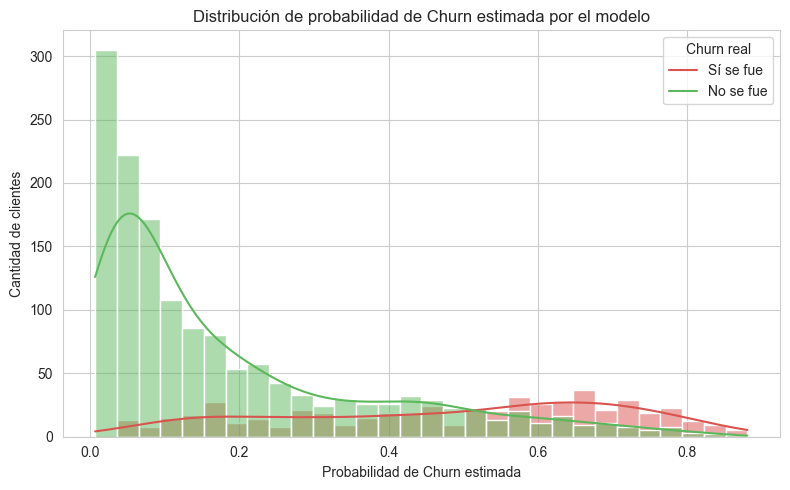

In [4]:
# ==============================================================================
# 4. DISTRIBUCIÓN DE PROBABILIDAD DE CHURN
# ==============================================================================
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df, x='probabilidad_churn', hue='churn_real',
    bins=30, kde=True, palette={0: '#5cb85c', 1: '#d9534f'}
)
plt.title('Distribución de probabilidad de Churn estimada por el modelo')
plt.xlabel('Probabilidad de Churn estimada')
plt.ylabel('Cantidad de clientes')
plt.legend(title='Churn real', labels=['Sí se fue', 'No se fue'])
plt.tight_layout()
plt.show()

## 5. Dashboard Visual Ejecutivo (impacto de negocio)
Aquí se traduce el riesgo de Churn en términos que el equipo de Marketing/Finanzas entiende directamente: cuántos clientes, cuánto dinero (MRR) y qué perfiles son los más vulnerables.

- **Alto riesgo (≥ 70%):** contacto inmediato.
- **Medio riesgo (40%–70%):** campañas preventivas.
- **Bajo riesgo (< 40%):** sin acción urgente.

**MRR (Monthly Recurring Revenue):** suma de `MonthlyCharges` de los clientes en cada banda — representa cuántos ingresos mensuales están en riesgo de perderse si esos clientes se van.

Impacto financiero por banda de riesgo (MRR = Ingreso Mensual Recurrente):
                 clientes MRR_total_fmt  tenure_promedio
segmento_riesgo                                         
Alto                  131    $11,481.75         6.251908
Medio                 434    $32,252.90        13.769585
Bajo                 1442    $88,052.20        41.381415


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_27544\3849636221.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 0], x='segmento_riesgo', data=df, order=['Alto', 'Medio', 'Bajo'], palette=colores_riesgo)
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_27544\3849636221.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x=resumen_financiero.index, y='MRR_total', data=resumen_financiero, palette=colores_riesgo)
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_27544\3849636221.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns

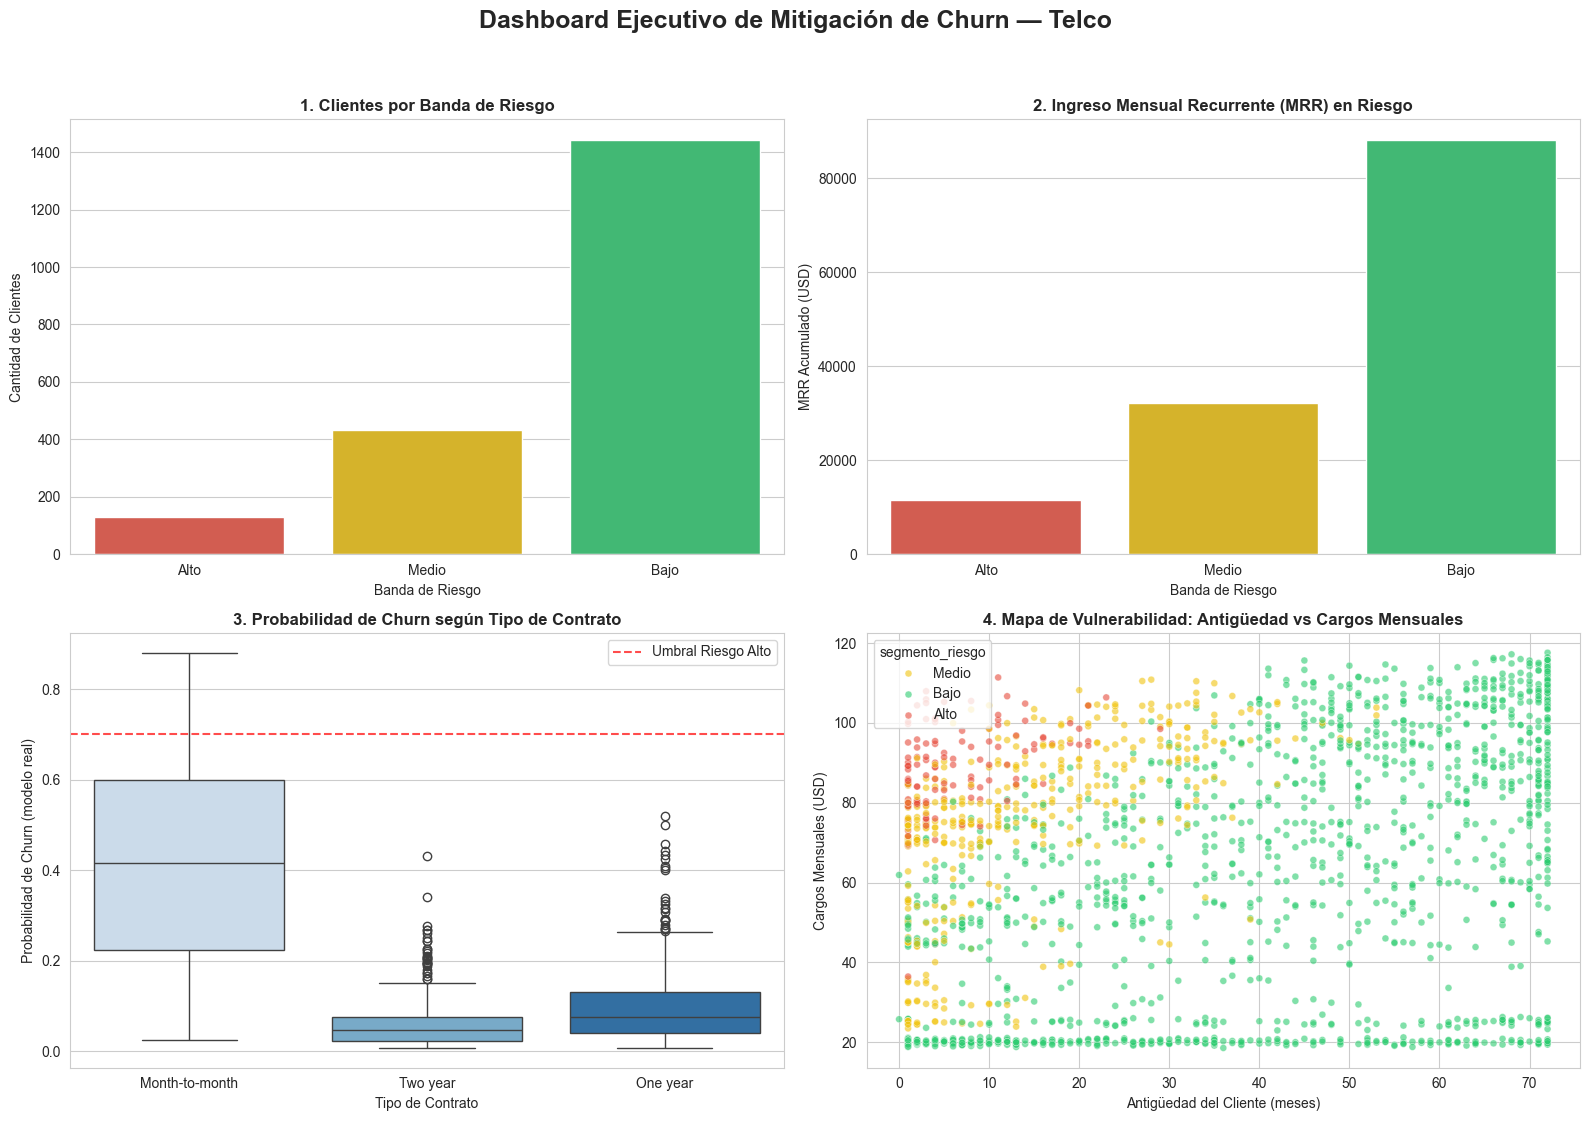

Imagen del dashboard exportada en: ../data/sample/dashboard_ejecutivo_fase4.png (lista para la sustentación)


In [5]:
# ==============================================================================
# 5. SEGMENTACIÓN DE RIESGO + IMPACTO FINANCIERO (MRR) + DASHBOARD 2x2
# ==============================================================================
def segmentar_riesgo(p):
    if p >= 0.70:
        return 'Alto'
    elif p >= 0.40:
        return 'Medio'
    else:
        return 'Bajo'

df['segmento_riesgo'] = df['probabilidad_churn'].apply(segmentar_riesgo)

resumen_financiero = df.groupby('segmento_riesgo').agg(
    clientes=('customerID', 'count'),
    MRR_total=('MonthlyCharges', 'sum'),
    tenure_promedio=('tenure', 'mean')
).reindex(['Alto', 'Medio', 'Bajo'])

resumen_financiero['MRR_total_fmt'] = resumen_financiero['MRR_total'].apply(lambda x: f"${x:,.2f}")

print("Impacto financiero por banda de riesgo (MRR = Ingreso Mensual Recurrente):")
print(resumen_financiero[['clientes', 'MRR_total_fmt', 'tenure_promedio']])

colores_riesgo = {'Alto': '#e74c3c', 'Medio': '#f1c40f', 'Bajo': '#2ecc71'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Dashboard Ejecutivo de Mitigación de Churn — Telco', fontsize=18, fontweight='bold', y=0.96)

# Panel 1: Volumen de clientes por banda de riesgo
sns.countplot(ax=axes[0, 0], x='segmento_riesgo', data=df, order=['Alto', 'Medio', 'Bajo'], palette=colores_riesgo)
axes[0, 0].set_title('1. Clientes por Banda de Riesgo', fontweight='bold')
axes[0, 0].set_xlabel('Banda de Riesgo')
axes[0, 0].set_ylabel('Cantidad de Clientes')

# Panel 2: MRR comprometido por banda de riesgo
sns.barplot(ax=axes[0, 1], x=resumen_financiero.index, y='MRR_total', data=resumen_financiero, palette=colores_riesgo)
axes[0, 1].set_title('2. Ingreso Mensual Recurrente (MRR) en Riesgo', fontweight='bold')
axes[0, 1].set_xlabel('Banda de Riesgo')
axes[0, 1].set_ylabel('MRR Acumulado (USD)')

# Panel 3: Probabilidad de Churn (real) según tipo de contrato
sns.boxplot(ax=axes[1, 0], x='Contract', y='probabilidad_churn', data=df, palette='Blues')
axes[1, 0].axhline(y=0.70, color='r', linestyle='--', alpha=0.7, label='Umbral Riesgo Alto')
axes[1, 0].legend()
axes[1, 0].set_title('3. Probabilidad de Churn según Tipo de Contrato', fontweight='bold')
axes[1, 0].set_xlabel('Tipo de Contrato')
axes[1, 0].set_ylabel('Probabilidad de Churn (modelo real)')

# Panel 4: Mapa de vulnerabilidad (antigüedad vs cargo mensual)
sns.scatterplot(
    ax=axes[1, 1], x='tenure', y='MonthlyCharges', hue='segmento_riesgo',
    data=df, palette=colores_riesgo, alpha=0.6, s=25
)
axes[1, 1].set_title('4. Mapa de Vulnerabilidad: Antigüedad vs Cargos Mensuales', fontweight='bold')
axes[1, 1].set_xlabel('Antigüedad del Cliente (meses)')
axes[1, 1].set_ylabel('Cargos Mensuales (USD)')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig('../data/sample/dashboard_ejecutivo_fase4.png', dpi=300, bbox_inches='tight')
plt.show()

print("Imagen del dashboard exportada en: ../data/sample/dashboard_ejecutivo_fase4.png (lista para la sustentación)")

## 6. Factores que más explican el Churn

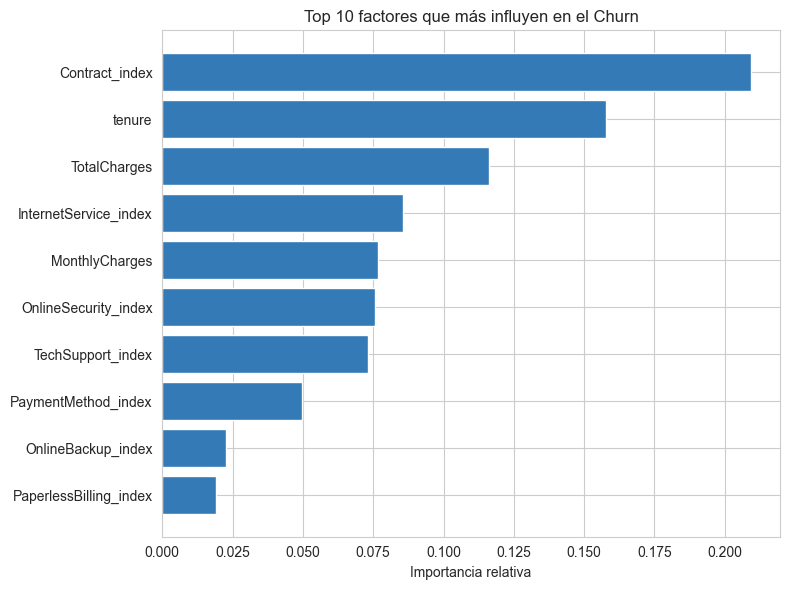

In [6]:
# ==============================================================================
# 6. TOP 10 VARIABLES QUE MÁS INFLUYEN EN EL CHURN (RANDOM FOREST)
# ==============================================================================
top10 = importancias.head(10).sort_values('importancia')

plt.figure(figsize=(8, 6))
plt.barh(top10['variable'], top10['importancia'], color='#337ab7')
plt.xlabel('Importancia relativa')
plt.title('Top 10 factores que más influyen en el Churn')
plt.tight_layout()
plt.show()

## 7. Lista priorizada de retención

In [7]:
# ==============================================================================
# 7. CLIENTES DE ALTO RIESGO A CONTACTAR DE INMEDIATO
# ==============================================================================
prioridad_retencion = df[df['segmento_riesgo'] == 'Alto'].sort_values('probabilidad_churn', ascending=False)

print(f"Clientes de ALTO riesgo a contactar de inmediato: {len(prioridad_retencion):,}")
print(f"MRR total en riesgo en este segmento: ${prioridad_retencion['MonthlyCharges'].sum():,.2f}")
prioridad_retencion[['customerID', 'Contract', 'MonthlyCharges', 'probabilidad_churn', 'churn_real']].head(20)

Clientes de ALTO riesgo a contactar de inmediato: 131
MRR total en riesgo en este segmento: $11,481.75


,customerID,Contract,MonthlyCharges,probabilidad_churn,churn_real
1048,5178-LMXOP,Month-to-month,95.10,0.880239,1
1315,6496-SLWHQ,Month-to-month,105.00,0.878366,1
246,1400-MMYXY,Month-to-month,105.90,0.877943,1
875,4424-TKOPW,Month-to-month,93.85,0.875580,1
1036,5150-ITWWB,Month-to-month,94.85,0.870879,0
1643,8098-LLAZX,Month-to-month,95.45,0.863680,1
646,3389-YGYAI,Month-to-month,105.50,0.850372,1
1217,6023-YEBUP,Month-to-month,100.95,0.849926,1
789,3988-RQIXO,Month-to-month,91.30,0.843713,1
249,1415-YFWLT,Month-to-month,89.30,0.842816,1


## 8. Exportar lista final para la campaña de retención

In [8]:
# ==============================================================================
# 8. EXPORTAR LISTA PARA POWER BI / CAMPAÑA DE RETENCIÓN
# ==============================================================================
prioridad_retencion[['customerID', 'Contract', 'MonthlyCharges', 'probabilidad_churn']].to_csv(
    '../data/sample/lista_retencion_prioritaria.csv', index=False
)

print("Lista de clientes prioritarios exportada en:")
print("../data/sample/lista_retencion_prioritaria.csv")
print("\nLa imagen del dashboard (dashboard_ejecutivo_fase4.png) ya quedó exportada en la sección 5.")

Lista de clientes prioritarios exportada en:
../data/sample/lista_retencion_prioritaria.csv

La imagen del dashboard (dashboard_ejecutivo_fase4.png) ya quedó exportada en la sección 5.


## 🏁 Conclusión y Próximos Pasos
- Este dashboard usa **probabilidades reales del modelo entrenado en la Fase 3** — nada está simulado ni calculado con reglas manuales. Eso es clave para que los resultados (incluyendo el MRR en riesgo) sean defendibles ante el profesor.
- **Power BI:** los archivos `predicciones_churn_dashboard.csv`, `importancia_variables_churn.csv`, `lista_retencion_prioritaria.csv` y la imagen `dashboard_ejecutivo_fase4.png` quedan listos en `data/sample/` para usarse como fuente de datos en Power BI o directamente en las diapositivas de la sustentación.
- **Pendiente del proyecto:** estos resultados corresponden todavía al dataset real de IBM (7,043 clientes). Cuando el dataset sintético peruano (500,000 clientes vía Faker, con ARPU y zona geográfica) esté listo, este mismo notebook funciona sin cambios — solo hay que volver a correr las Fases 2 y 3 sobre los nuevos datos.